# MGA Analysis: Multiple Slack Values

Analyze results from MGA optimization with multiple cost slack tolerances to understand the trade-off between solution diversity and cost increase.

## Overview
- **Input**: NetworkCollection from model_trade with multiple slack values
- **Purpose**: Compare solutions across different slack tolerances
- **Key metrics**: Cost, trade patterns, HBI production by region

In [10]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import pypsa

%matplotlib inline
sns.set_style("whitegrid")

## Load Data

Load the NetworkCollection from netCDF files with different slack values.

In [11]:
from _helpers import mock_snakemake
import glob
import os

snakemake = mock_snakemake(
    "model_trade",
    cost_year="2050",
    interone="hbi",
    intertwo="eaf-grid",
    final="steel",
    scenario="mga-new-indicators-multiple",
)

# Get the base output path
output_base = str(snakemake.output.trade_network)
output_dir = os.path.dirname(output_base)
output_base_name = os.path.splitext(os.path.basename(output_base))[0]

print(f"Looking for networks in: {output_dir}")
print(f"Base name: {output_base_name}")

# Find all network files for this scenario
pattern = os.path.join(output_dir, f"{output_base_name}_*.nc")
network_files = sorted(glob.glob(pattern))

print(f"\nFound {len(network_files)} network files:")
for f in network_files:
    print(f"  - {os.path.basename(f)}")

Looking for networks in: /mnt/c/Users/scl38887/Documents/git/shift/results/cost_year~2050/interone~hbi/intertwo~eaf-grid/final~steel/scenario~mga-new-indicators-multiple
Base name: network

Found 8 network files:
  - network_0.01.nc
  - network_0.02.nc
  - network_0.03.nc
  - network_0.04.nc
  - network_0.05.nc
  - network_0.07.nc
  - network_0.1.nc
  - network_nan.nc


In [12]:
# Load networks and extract slack values
networks = {}
slack_values = []

for filepath in network_files:
    # Extract slack value from filename (e.g., "network_0.005.nc" -> 0.005)
    filename = os.path.basename(filepath)
    slack_str = filename.split('_')[-1].replace('.nc', '')
    try:
        slack_value = float(slack_str)
        slack_values.append(slack_value)
        networks[slack_value] = pypsa.Network(filepath)
        print(f"Loaded slack={slack_value} from {filename}")
    except ValueError:
        print(f"Could not parse slack value from {filename}, skipping")

slack_values = sorted(slack_values)
print(f"\nLoaded {len(networks)} networks with slack values: {slack_values}")

INFO:pypsa.network.io:Imported network 'Unnamed Network' has buses, carriers, generators, links, loads, sub_networks
INFO:pypsa.network.io:Imported network 'Unnamed Network' has buses, carriers, generators, links, loads, sub_networks
INFO:pypsa.network.io:Imported network 'Unnamed Network' has buses, carriers, generators, links, loads, sub_networks


Loaded slack=0.01 from network_0.01.nc
Loaded slack=0.02 from network_0.02.nc


INFO:pypsa.network.io:Imported network 'Unnamed Network' has buses, carriers, generators, links, loads, sub_networks


Loaded slack=0.03 from network_0.03.nc


INFO:pypsa.network.io:Imported network 'Unnamed Network' has buses, carriers, generators, links, loads, sub_networks
INFO:pypsa.network.io:Imported network 'Unnamed Network' has buses, carriers, generators, links, loads, sub_networks
INFO:pypsa.network.io:Imported network 'Unnamed Network' has buses, carriers, generators, links, loads, sub_networks


Loaded slack=0.04 from network_0.04.nc
Loaded slack=0.05 from network_0.05.nc


INFO:pypsa.network.io:Imported network 'Unnamed Network' has buses, carriers, generators, links, loads, sub_networks
INFO:pypsa.network.io:Imported network 'Unnamed Network' has buses, carriers, generators, links, loads, sub_networks
INFO:pypsa.network.io:Imported network 'Unnamed Network' has buses, carriers, generators, links, loads, sub_networks


Loaded slack=0.07 from network_0.07.nc
Loaded slack=0.1 from network_0.1.nc


INFO:pypsa.network.io:Imported network 'Unnamed Network' has buses, carriers, generators, links, loads, sub_networks


Loaded slack=nan from network_nan.nc

Loaded 8 networks with slack values: [0.01, 0.02, 0.03, 0.04, 0.05, 0.07, 0.1, nan]


## Cost Analysis

Compare total costs and cost breakdown across different slack tolerances.

 slack  capex_B€     opex_B€    total_B€
  0.01  0.014569 1510.972513 1510.987081
  0.02  0.014432 1525.932917 1525.947349
  0.03  0.014172 1540.893445 1540.907617
  0.04  0.013960 1555.778720 1555.792680
  0.05  0.014173 1570.401952 1570.416124
  0.07  0.014660 1599.519940 1599.534601
  0.10  0.015321 1643.154208 1643.169529
   NaN  0.016210 1496.010603 1496.026813


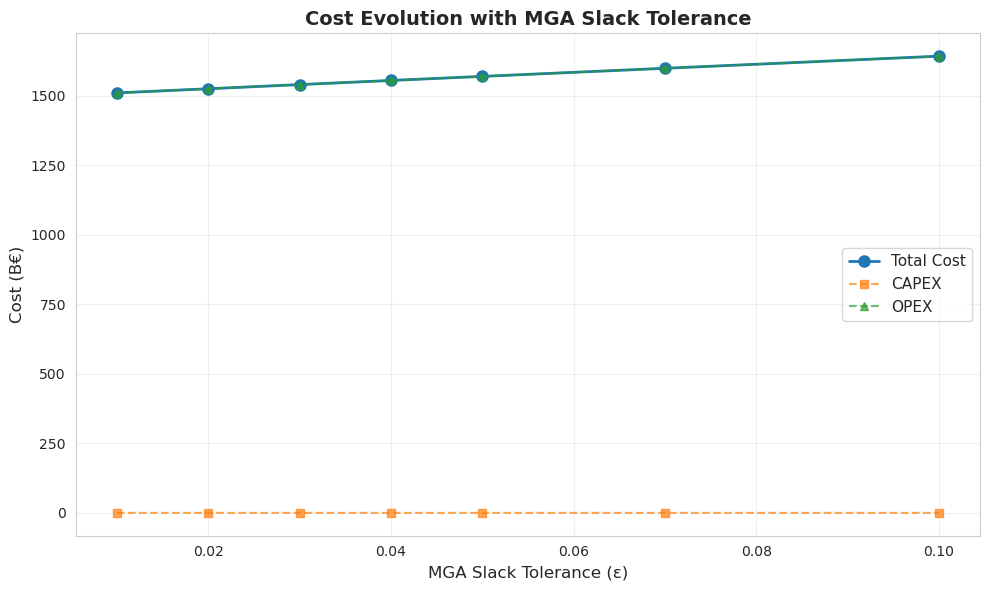


Cost increase relative to minimum:
 slack    total_B€  cost_increase_B€  cost_increase_%
  0.01 1510.987081         14.960268         1.000000
  0.02 1525.947349         29.920536         2.000000
  0.03 1540.907617         44.880804         3.000000
  0.04 1555.792680         59.765867         3.994973
  0.05 1570.416124         74.389312         4.972458
  0.07 1599.534601        103.507788         6.918846
  0.10 1643.169529        147.142717         9.835567
   NaN 1496.026813          0.000000         0.000000


In [13]:
# Extract cost information
results = []

for slack, network in networks.items():
    capex = network.statistics.capex()
    opex = network.statistics.opex()
    
    capex_total = capex.sum().sum() / 1e9  # Convert to B€
    opex_total = opex.sum().sum() / 1e9
    total_cost = capex_total + opex_total
    
    results.append({
        'slack': slack,
        'capex_B€': capex_total,
        'opex_B€': opex_total,
        'total_B€': total_cost,
    })

cost_df = pd.DataFrame(results)
print(cost_df.to_string(index=False))

# Plot cost evolution
fig, ax = plt.subplots(figsize=(10, 6))

ax.plot(cost_df['slack'], cost_df['total_B€'], 'o-', linewidth=2, markersize=8, label='Total Cost')
ax.plot(cost_df['slack'], cost_df['capex_B€'], 's--', linewidth=1.5, markersize=6, alpha=0.7, label='CAPEX')
ax.plot(cost_df['slack'], cost_df['opex_B€'], '^--', linewidth=1.5, markersize=6, alpha=0.7, label='OPEX')

ax.set_xlabel('MGA Slack Tolerance (ε)', fontsize=12)
ax.set_ylabel('Cost (B€)', fontsize=12)
ax.set_title('Cost Evolution with MGA Slack Tolerance', fontsize=14, fontweight='bold')
ax.legend(fontsize=11)
ax.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

# Cost increase relative to minimum
cost_df['cost_increase_B€'] = cost_df['total_B€'] - cost_df['total_B€'].min()
cost_df['cost_increase_%'] = 100 * cost_df['cost_increase_B€'] / cost_df['total_B€'].min()

print("\nCost increase relative to minimum:")
print(cost_df[['slack', 'total_B€', 'cost_increase_B€', 'cost_increase_%']].to_string(index=False))

## HBI Production by Region

Analyze how HBI production distribution changes with slack tolerance.


HBI Production (Mt) by Region:
                             0.01          0.02          0.03          0.04  \
region                                                                        
East_Asia            1.055917e+09  1.055917e+09  1.257978e+09  1.253210e+09   
North_West_Africa    9.895367e+08  6.901527e+08  4.227149e+08  2.617458e+08   
Middle_East          8.367113e+08  8.677116e+08  8.677116e+08  8.658438e+08   
Oceania              3.172775e+08  3.172775e+08  3.380200e+08  5.009848e+08   
North_America        3.086405e+08  3.863332e+08  3.863332e+08  3.919284e+08   
South_America        2.119575e+08  4.069982e+08  4.541964e+08  4.398470e+08   
Subsaharan_Africa    1.396695e+08  1.396695e+08  1.396695e+08  1.371498e+08   
Eurasia              1.074738e+08  1.074738e+08  1.074738e+08  1.057798e+08   
South_South_America  2.672195e+07  2.672195e+07  2.672195e+07  2.926126e+07   
Central_America      0.000000e+00  0.000000e+00  0.000000e+00  1.692179e+07   
East_East_Asia      

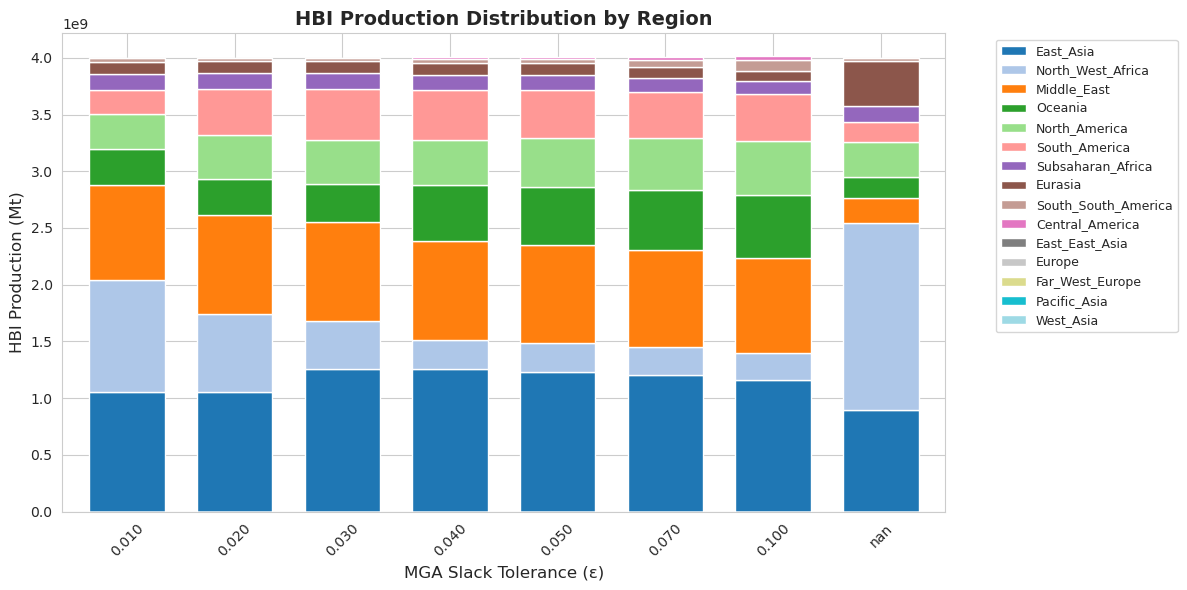

In [14]:
# Extract HBI production by region for each slack
hbi_production = {}

for slack, network in networks.items():
    # Get all HBI generators (links from ore to HBI)
    hbi_gen = network.links[
        (network.links.carrier == 'hbi') & 
        (network.links.bus1.str.contains('_hbi'))
    ].copy()
    
    # Extract region from bus name
    hbi_gen['region'] = hbi_gen['bus1'].str.replace('_hbi', '')
    
    # Sum p_nom_opt by region
    regional_hbi = hbi_gen.groupby('region')['p_nom_opt'].sum()
    hbi_production[slack] = regional_hbi

# Create DataFrame with regions as rows and slacks as columns
hbi_df = pd.DataFrame(hbi_production).fillna(0)
hbi_df = hbi_df.sort_values(by=list(hbi_df.columns), ascending=False)

print("\nHBI Production (Mt) by Region:")
print(hbi_df.round(2))

# Plot stacked bar chart
fig, ax = plt.subplots(figsize=(12, 6))

hbi_df.T.plot(kind='bar', stacked=True, ax=ax, width=0.7, colormap='tab20')

ax.set_xlabel('MGA Slack Tolerance (ε)', fontsize=12)
ax.set_ylabel('HBI Production (Mt)', fontsize=12)
ax.set_title('HBI Production Distribution by Region', fontsize=14, fontweight='bold')
ax.legend(bbox_to_anchor=(1.05, 1), loc='upper left', fontsize=9)
ax.set_xticklabels([f"{s:.3f}" for s in slack_values], rotation=45)

plt.tight_layout()
plt.show()

## HBI Trade Patterns

Analyze shipping distances and patterns across different slack scenarios.


HBI Trade Summary:
       Total Trade (Mt)  Mean Link Capacity (Mt)      Std Dev  Number of Links
slack                                                                         
0.01       1.550724e+09               7384402.28  54352128.31              210
0.02       1.533963e+09               7304586.08  53647753.41              210
0.03       1.397956e+09               6656935.47  44653216.88              210
0.04       1.406390e+09               6697095.66  41492426.23              210
0.05       1.462326e+09               6963459.51  40794253.21              210
0.07       1.532740e+09               7298759.67  40206175.10              210
0.10       1.661157e+09               7910271.58  39405668.78              210


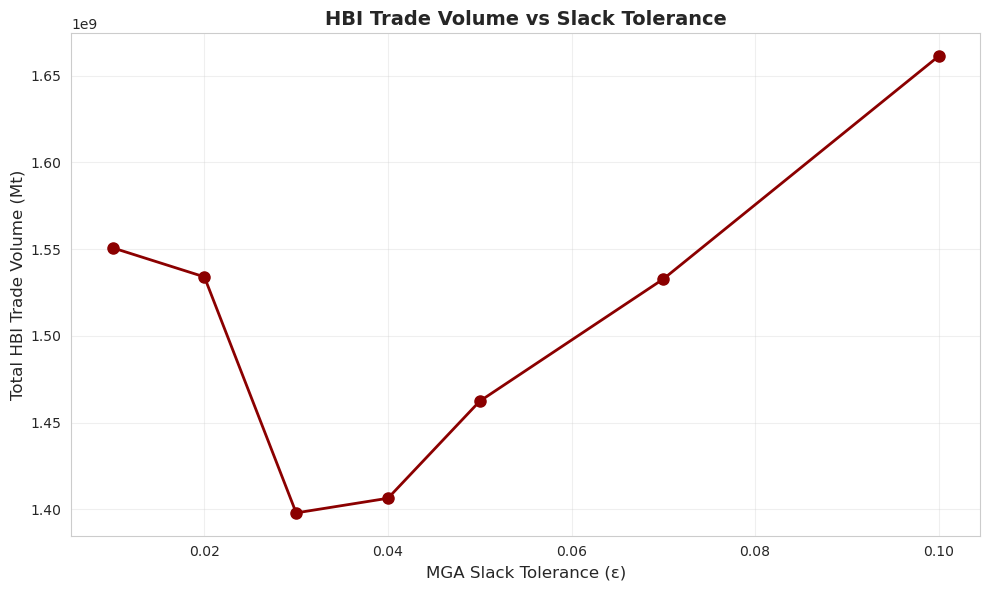

In [15]:
# Extract HBI trade links
trade_data = []

for slack, network in networks.items():
    hbi_trade = network.links[
        network.links.carrier == 'shipping_hbi'
    ].copy()
    
    hbi_trade['slack'] = slack
    hbi_trade['total_trade'] = hbi_trade.groupby('slack')['p_nom_opt'].transform('sum')
    trade_data.append(hbi_trade)

trade_df = pd.concat(trade_data, ignore_index=True)

# Summary by slack
trade_summary = trade_df.groupby('slack')['p_nom_opt'].agg(['sum', 'mean', 'std', 'count'])
trade_summary.columns = ['Total Trade (Mt)', 'Mean Link Capacity (Mt)', 'Std Dev', 'Number of Links']

print("\nHBI Trade Summary:")
print(trade_summary.round(2))

# Plot total trade vs slack
fig, ax = plt.subplots(figsize=(10, 6))

trade_by_slack = trade_df.groupby('slack')['p_nom_opt'].sum()
ax.plot(trade_by_slack.index, trade_by_slack.values, 'o-', linewidth=2, markersize=8, color='darkred')

ax.set_xlabel('MGA Slack Tolerance (ε)', fontsize=12)
ax.set_ylabel('Total HBI Trade Volume (Mt)', fontsize=12)
ax.set_title('HBI Trade Volume vs Slack Tolerance', fontsize=14, fontweight='bold')
ax.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

## Exporter Diversity

Analyze how many unique exporters/suppliers are active at different slack tolerances.
This shows the diversity of solutions.


Exporter Diversity Analysis:
 slack  unique_exporters  active_trade_links  herfindahl_index concentration
  0.01                 6                   9          0.308607          High
  0.02                13                  31          0.270775        Medium
  0.03                 7                  12          0.234983        Medium
  0.04                11                 154          0.207586        Medium
  0.05                11                 154          0.198257        Medium
  0.07                11                 154          0.186844        Medium
  0.10                11                 154          0.171489        Medium
   NaN                 5                   8          0.342358          High


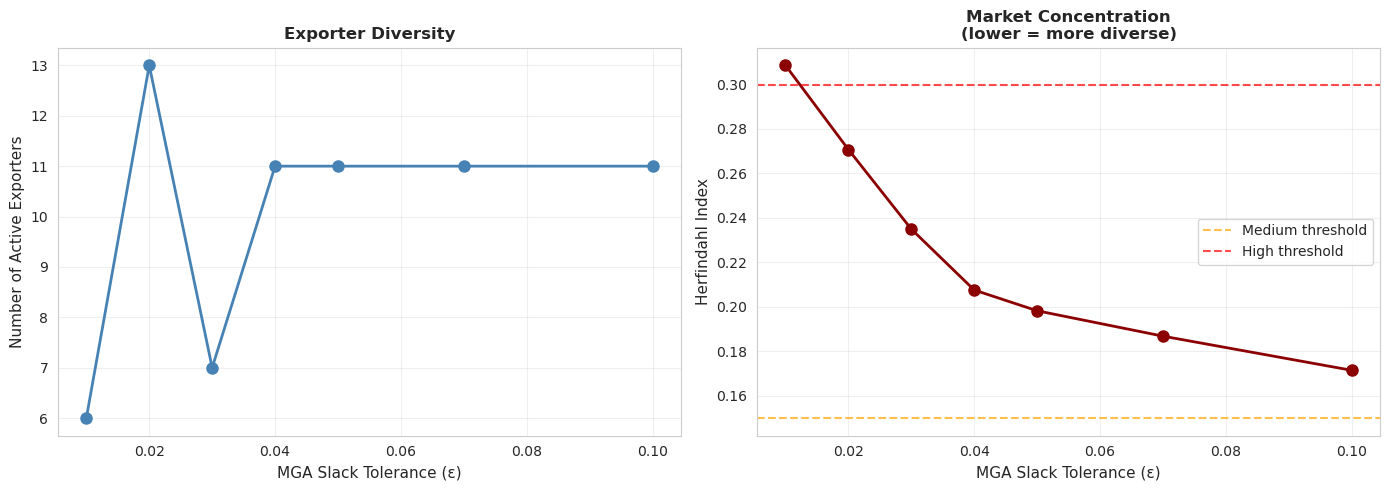

In [16]:
# Analyze exporter concentration
exporter_data = []

for slack, network in networks.items():
    hbi_trade = network.links[
        network.links.carrier == 'shipping_hbi'
    ].copy()
    
    # Only include links with non-zero flow
    active_links = hbi_trade[hbi_trade['p_nom_opt'] > 1e-6]
    
    if len(active_links) > 0:
        # Count unique exporters (bus0 with _hbi)
        unique_exporters = active_links['bus0'].nunique()
        # Count unique importers (bus1 with _hbi)
        unique_importers = active_links['bus1'].nunique()
        # Herfindahl index (concentration measure)
        market_shares = active_links.groupby('bus0')['p_nom_opt'].sum() / active_links['p_nom_opt'].sum()
        herfindahl = (market_shares ** 2).sum()
        
        exporter_data.append({
            'slack': slack,
            'unique_exporters': unique_exporters,
            'unique_importers': unique_importers,
            'active_trade_links': len(active_links),
            'herfindahl_index': herfindahl,
            'concentration': 'High' if herfindahl > 0.3 else 'Medium' if herfindahl > 0.15 else 'Low'
        })

exporter_df = pd.DataFrame(exporter_data)

print("\nExporter Diversity Analysis:")
print(exporter_df[['slack', 'unique_exporters', 'active_trade_links', 'herfindahl_index', 'concentration']].to_string(index=False))

# Plot diversity metrics
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 5))

# Number of active exporters
ax1.plot(exporter_df['slack'], exporter_df['unique_exporters'], 'o-', linewidth=2, markersize=8, color='steelblue')
ax1.set_xlabel('MGA Slack Tolerance (ε)', fontsize=11)
ax1.set_ylabel('Number of Active Exporters', fontsize=11)
ax1.set_title('Exporter Diversity', fontsize=12, fontweight='bold')
ax1.grid(True, alpha=0.3)

# Herfindahl index (lower = more diverse)
ax2.plot(exporter_df['slack'], exporter_df['herfindahl_index'], 'o-', linewidth=2, markersize=8, color='darkred')
ax2.axhline(y=0.15, color='orange', linestyle='--', alpha=0.7, label='Medium threshold')
ax2.axhline(y=0.3, color='red', linestyle='--', alpha=0.7, label='High threshold')
ax2.set_xlabel('MGA Slack Tolerance (ε)', fontsize=11)
ax2.set_ylabel('Herfindahl Index', fontsize=11)
ax2.set_title('Market Concentration\n(lower = more diverse)', fontsize=12, fontweight='bold')
ax2.legend(fontsize=10)
ax2.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

## Regional Exporter Analysis

Detailed breakdown of which regions export at different slack levels.


HBI Exports by Region (Mt):
                             0.01          0.02          0.03          0.04  \
exporter                                                                      
Central_America      0.000000e+00  0.000000e+00  0.000000e+00  1.349026e+06   
East_Asia            1.014562e+08  1.014562e+08  2.285384e+08  2.263717e+08   
East_East_Asia       0.000000e+00  0.000000e+00  0.000000e+00  1.244783e+06   
Eurasia              0.000000e+00  0.000000e+00  0.000000e+00  0.000000e+00   
Europe               0.000000e+00  0.000000e+00  0.000000e+00  2.043763e+06   
Far_West_Europe      0.000000e+00  0.000000e+00  0.000000e+00  1.323445e+06   
Middle_East          6.917910e+08  6.917910e+08  5.531997e+08  4.545708e+08   
North_America        8.505875e+07  1.339221e+08  1.339221e+08  1.383570e+08   
North_West_Africa    4.569067e+08  2.686149e+08  1.004149e+08  0.000000e+00   
Oceania              1.915175e+08  1.915175e+08  2.045631e+08  3.077564e+08   
Pacific_Asia         0.

/tmp/ipykernel_1303/57846608.py:32: UserWarning:

marker is redundantly defined by the 'marker' keyword argument and the fmt string "o-" (-> marker='o'). The keyword argument will take precedence.



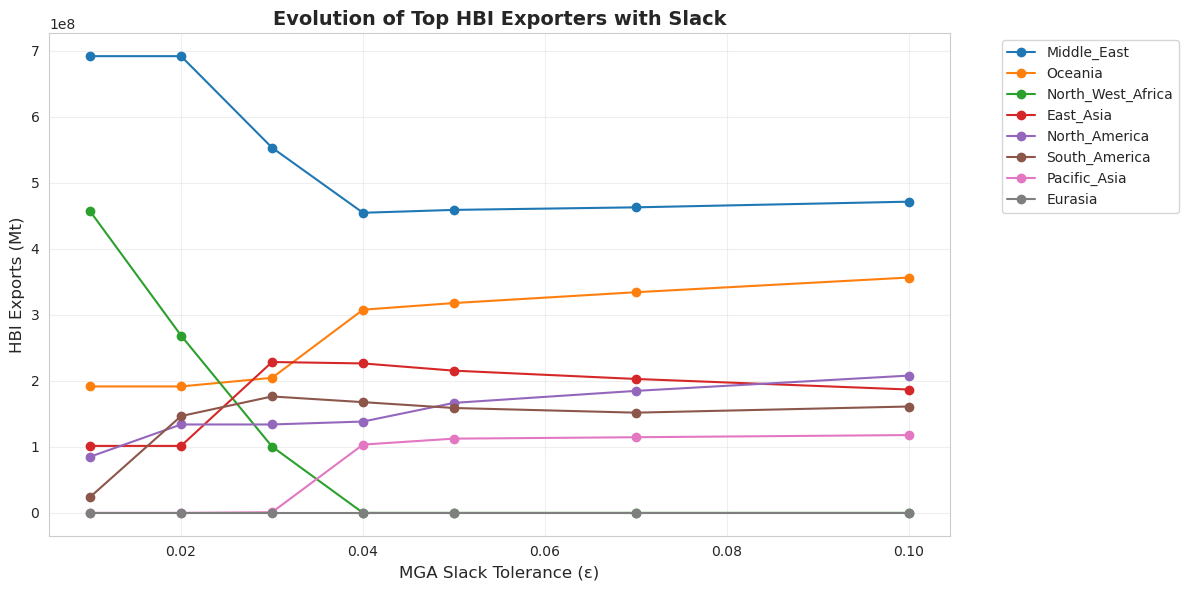

In [17]:
# Regional exporter contribution
regional_export = {}

for slack, network in networks.items():
    hbi_trade = network.links[
        (network.links.carrier == 'shipping_hbi') &
        (network.links['p_nom_opt'] > 1e-6)
    ].copy()
    
    # Extract exporter region from bus0
    hbi_trade['exporter'] = hbi_trade['bus0'].str.replace('_hbi', '')
    
    # Sum by exporter
    exporter_totals = hbi_trade.groupby('exporter')['p_nom_opt'].sum().sort_values(ascending=False)
    regional_export[slack] = exporter_totals

# Create DataFrame
export_df = pd.DataFrame(regional_export).fillna(0)

print("\nHBI Exports by Region (Mt):")
print(export_df.round(2))

# Identify regions selected by indicator (stability < 30)
print("\nNote: Regions with political stability < 30 are the MGA targets for minimization")

# Plot evolution of top exporters
fig, ax = plt.subplots(figsize=(12, 6))

top_exporters = export_df.sum(axis=1).nlargest(8).index

for exporter in top_exporters:
    ax.plot(export_df.columns, export_df.loc[exporter], 'o-', marker='o', markersize=6, label=exporter)

ax.set_xlabel('MGA Slack Tolerance (ε)', fontsize=12)
ax.set_ylabel('HBI Exports (Mt)', fontsize=12)
ax.set_title('Evolution of Top HBI Exporters with Slack', fontsize=14, fontweight='bold')
ax.legend(bbox_to_anchor=(1.05, 1), loc='upper left', fontsize=10)
ax.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

## Summary and Insights

Key findings from MGA analysis across multiple slack tolerances.

In [18]:
# Generate summary statistics
print("=" * 70)
print("MGA ANALYSIS SUMMARY")
print("=" * 70)

print(f"\nNumber of Slack Scenarios: {len(slack_values)}")
print(f"Slack Range: {min(slack_values):.1%} to {max(slack_values):.1%}")

print("\n--- COST ANALYSIS ---")
min_cost = cost_df['total_B€'].min()
max_cost = cost_df['total_B€'].max()
print(f"Minimum Cost (slack={cost_df.loc[cost_df['total_B€'].idxmin(), 'slack']:.3f}): {min_cost:.2f} B€")
print(f"Maximum Cost (slack={cost_df.loc[cost_df['total_B€'].idxmax(), 'slack']:.3f}): {max_cost:.2f} B€")
print(f"Cost Range: {max_cost - min_cost:.2f} B€ ({100*(max_cost-min_cost)/min_cost:.1f}%)")

print("\n--- TRADE DIVERSITY ---")
min_exports = exporter_df['unique_exporters'].min()
max_exports = exporter_df['unique_exporters'].max()
print(f"Minimum Exporters: {min_exports} (slack={exporter_df.loc[exporter_df['unique_exporters'].idxmin(), 'slack']:.3f})")
print(f"Maximum Exporters: {max_exports} (slack={exporter_df.loc[exporter_df['unique_exporters'].idxmax(), 'slack']:.3f})")

print("\n--- INTERPRETATION ---")
print("""
Slack tolerance (ε) allows solutions that increase cost by up to ε·cost_optimal.
- Low slack (0.5%) → Most cost-optimal, potentially concentrated solutions
- High slack (5%) → More diverse suppliers, less concentrated, higher cost
- The Pareto frontier shows the cost-diversity trade-off
""")

print("=" * 70)

MGA ANALYSIS SUMMARY

Number of Slack Scenarios: 8
Slack Range: 1.0% to 10.0%

--- COST ANALYSIS ---
Minimum Cost (slack=nan): 1496.03 B€
Maximum Cost (slack=0.100): 1643.17 B€
Cost Range: 147.14 B€ (9.8%)

--- TRADE DIVERSITY ---
Minimum Exporters: 5 (slack=nan)
Maximum Exporters: 13 (slack=0.020)

--- INTERPRETATION ---

Slack tolerance (ε) allows solutions that increase cost by up to ε·cost_optimal.
- Low slack (0.5%) → Most cost-optimal, potentially concentrated solutions
- High slack (5%) → More diverse suppliers, less concentrated, higher cost
- The Pareto frontier shows the cost-diversity trade-off

